<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/HW4/Homework4_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 2

In [159]:
# set random seed
import os, random
import numpy as np
import torch
def seed_everything(seed: int = 42):
 random.seed(seed)
 np.random.seed(seed)
 os.environ["PYTHONHASHSEED"] = str(seed)
 torch.manual_seed(seed)
 torch.cuda.manual_seed_all(seed)
 torch.backends.cudnn.benchmark = False
 torch.backends.cudnn.deterministic = True

seed_everything(42)
rng = np.random.default_rng(42)

The dataset I will be using is this [Google Stock Prediction](https://www.kaggle.com/datasets/shreenidhihipparagi/google-stock-prediction) dataset on Kaggle.

Its license is [Database: Open Database, Contents: Database Contents](http://opendatacommons.org/licenses/dbcl/1.0/) and it was uploaded to Kaggle by Shreenidhi Hipparagi.

In [160]:
import pandas as pd

path = 'GOOG.csv'
data = pd.read_csv(path)
data.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0


As we can see, this Stock Prediction dataset has a symbol (all GOOG since it is google stocks), timestamp (day), and values for the stock for that day (high, low, open, close, and adjusted values).

The problem we are hoping to solve with our model is to be able to predict the open and close stock values for some day. We need to use a sequence model for this task as the predictions for the next stock price should be based on the stock prices of the previous days.

##Part 1: Implement RNN

First, I will preprocess the data:

In [161]:
# check types and look for null values
print(data.info())
print(data.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB
None
Index(['symbol', 'date', 'close', 'high', 'low', 'open', 'volume', 'adjClose',
       'adjHigh', 'adjLow', 'adjOpen', 'adjVolume', 'divCash', 'splitFac

In [162]:
# preprocess data
from sklearn.preprocessing import MinMaxScaler

# convert dates to datetime instead of object
data['date'] = pd.to_datetime(data['date'])

# ensure we are ordering data by date
data = data.sort_values(by='date')
data = data.reset_index(drop=True)

# separate features (x) from targets (y)
label_cols = ['adjOpen', 'adjClose']
for l in label_cols:
  assert l in data.columns, f"Label column {l} not in data"

# all symbols are GOOG as we only use google stock prices, so drop
# drop non-adjusted prices because they correlate with adjusted and adjusted is cleaner
# drop date to prevent overfitting
drop_cols = ['symbol', 'date', 'high', 'low', 'open', 'close', 'volume']
x = data.drop(columns=drop_cols)
y = data[label_cols].shift(-1) # shift by 1, goal is to predict next day in data

# drop last row which has a null target (due to shifting)
data = data.iloc[:-1]
x = x.iloc[:-1]
y = y.iloc[:-1]

# train/val/test split (done manually since we want to keep sequential order)
# 70/15/15 split
split_index = int(len(data) * 0.7)
x_train, x_test, y_train, y_test = x[:split_index], x[split_index:], y[:split_index], y[split_index:]
x_val, x_test, y_val, y_test = x_test[:len(x_test)//2], x_test[len(x_test)//2:], y_test[:len(y_test)//2], y_test[len(y_test)//2:]

# scale data
# to prevent leakage, we fit_transform on the train data and just transform on the rest
scalerX = MinMaxScaler()
scalerY = MinMaxScaler()

x_train = scalerX.fit_transform(x_train)
y_train = scalerY.fit_transform(y_train)

x_val = scalerX.transform(x_val)
y_val = scalerY.transform(y_val)
x_test = scalerX.transform(x_test)
y_test = scalerY.transform(y_test)

# convert data to sequences
sequence_length = 30 # look back 30 days
x_train_sequences = []
y_train_sequences = []
for i in range(len(x_train) - sequence_length):
  x_train_sequences.append(x_train[i:i+sequence_length])
  y_train_sequences.append(y_train[i+sequence_length])

x_val_sequences = []
y_val_sequences = []
for i in range(len(x_val) - sequence_length):
  x_val_sequences.append(x_val[i:i+sequence_length])
  y_val_sequences.append(y_val[i+sequence_length])

x_test_sequences = []
y_test_sequences = []
for i in range(len(x_test) - sequence_length):
  x_test_sequences.append(x_test[i:i+sequence_length])
  y_test_sequences.append(y_test[i+sequence_length])

The framework I chose to use to implement my RNN was Pytorch.

In [163]:
# convert data to numpy array to make pytorch creation faster
# and avoid warnings
x_train_sequences = np.array(x_train_sequences)
y_train_sequences = np.array(y_train_sequences)
x_val_sequences = np.array(x_val_sequences)
y_val_sequences = np.array(y_val_sequences)
x_test_sequences = np.array(x_test_sequences)
y_test_sequences = np.array(y_test_sequences)

# print information about the new shape of our x and y
print("x shape (samples, sequence_length, features):", x_train_sequences.shape)
print("y shape (samples, targets):", y_train_sequences.shape)

# convert data to pytorch tensors
x_train_sequences = torch.tensor(x_train_sequences, dtype=torch.float32)
y_train_sequences = torch.tensor(y_train_sequences, dtype=torch.float32)
x_val_sequences = torch.tensor(x_val_sequences, dtype=torch.float32)
y_val_sequences = torch.tensor(y_val_sequences, dtype=torch.float32)
x_test_sequences = torch.tensor(x_test_sequences, dtype=torch.float32)
y_test_sequences = torch.tensor(y_test_sequences, dtype=torch.float32)

x shape (samples, sequence_length, features): (849, 30, 7)
y shape (samples, targets): (849, 2)


In [164]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_train_sequences = x_train_sequences.to(device)
y_train_sequences = y_train_sequences.to(device)
x_val_sequences = x_val_sequences.to(device)
y_val_sequences = y_val_sequences.to(device)

# create pytorch datasets
train_dataset = TensorDataset(x_train_sequences, y_train_sequences)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

val_dataset = TensorDataset(x_val_sequences, y_val_sequences)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# RNN class
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=1):
    super().__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    # initialize hidden state with 0
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

    # forward propagate, get output of shape (batch_size, sequence_length, hidden_size)
    out, _ = self.rnn(x, h0)

    # return output of last time step with shape (batch_size, hidden_size)
    out = self.fc(out[:, -1, :])
    return out

In [165]:
# function to create a model
def create_model(input_size, hidden_size, output_size, num_layers=1, lr=0.001):
  model = RNN(input_size, hidden_size, output_size, num_layers).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  return model, criterion, optimizer

In [166]:
# training function
# we return losses so we can visualize them later
def train(model, train_loader, criterion, optimizer, epochs, print_step=None):
  train_losses = []
  val_losses = []
  for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
      pred = model(xb)
      loss = criterion(pred, yb)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      total_train_loss += loss.item()
    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
      total_val_loss = 0
      for xb, yb in val_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        total_val_loss += loss.item()
      val_losses.append(total_val_loss / len(val_loader))

    if print_step is not None and epoch % print_step == 0:
      print(f"Epoch {epoch}, Train loss: {train_losses[-1]:.4f}, Val loss: {val_losses[-1]:.4f}")
  return train_losses, val_losses

In [190]:
# create RNN
seed_everything(42) # for reproducability
model, criterion, optimizer = create_model(x_train_sequences.shape[-1], 128, y_train_sequences.shape[-1], 2)
train_losses, val_losses = train(model, train_loader, criterion, optimizer, 50, 10)

Epoch 0, Train loss: 0.0120, Val loss: 0.0264
Epoch 10, Train loss: 0.0021, Val loss: 0.0063
Epoch 20, Train loss: 0.0020, Val loss: 0.0050
Epoch 30, Train loss: 0.0019, Val loss: 0.0047
Epoch 40, Train loss: 0.0020, Val loss: 0.0056


For my RNN model, the structure starts with an input sequence covering 30 days (my chosen sequence length) and 7 features (number of features in x). The RNN activation function `nn.RNN`, which is 2 layers, transforms the 7 input features to 128 features (as this is our hidden size), so we end up with a sequence of 30 days and 128 features. We then take the last day in the sequence and transform this to our output using `nn.Linear`, giving us 2 output values (2 is the number of targets).

So, during training we give the model a batch input of shape (batch_size, sequence_length, input_size), or (32, 30, 7). The RNN activatation function turns the shape into (32, 30, 128). Then, we take the last day in the sequence to get shape (32, 128), and use the linear activation function to get a shape of (32, 2).

The activation function used by `nn.RNN` is a tanh activation function, so each timestep computes $h_t = \tanh(x_tW_{ih}^{T} + b_{ih} + h_{t-1}W_{hh}^{T} + b_{hh})$, where $h_t$ is the hidden state at time $t$, $x_t$ is the input at time $t$, $W_{ih}$ is the input to hidden weight matrix, $h_{t-1}$ is the hidden state at time $t-1$ (previous hidden state), $W_{hh}$ is the hidden to hidden weight matrix, and $b_{ih}$ and $b_{hh}$ are the bias for input to hidden and hidden to hidden. (Note: this formula was taken from the [Pytorch documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html)). The tanh activation function maps the values to a range between -1 and 1.

I will evaluate the model using RMSE (root mean squared error) to get the approximate amount in dollars the model is off by:

In [191]:
from sklearn.metrics import root_mean_squared_error

# evaluate model
model.eval()
with torch.no_grad():
  pred = model(x_val_sequences)

  # convert from scaled back to original
  pred = scalerY.inverse_transform(pred.cpu().numpy())
  actual = scalerY.inverse_transform(y_val_sequences.cpu().numpy())

  print(f"Validation RMSE: ${root_mean_squared_error(actual, pred):.2f}")

  x_test_sequences = x_test_sequences.to(device)
  y_test_sequences = y_test_sequences.to(device)
  pred = model(x_test_sequences)

  # convert from scaled back to original
  pred = scalerY.inverse_transform(pred.cpu().numpy())
  actual = scalerY.inverse_transform(y_test_sequences.cpu().numpy())

  print(f"Test RMSE: ${root_mean_squared_error(actual, pred):.2f}")

print(f"Max stock price: {max(data["adjHigh"])}")
print(f"Min stock price: {min(data["adjLow"])}")

averageClose = sum(data["adjClose"]) / len(data["adjClose"])
averageOpen = sum(data["adjOpen"]) / len(data["adjOpen"])
print(f"Average stock price for close, open is {averageClose:.2f}, {averageOpen:.2f}")

Validation RMSE: $46.16
Test RMSE: $202.58
Max stock price: 2523.26
Min stock price: 663.284
Average stock price for close, open is 1215.28, 1214.22


As we can see, the vanilla RNN model has a RMSE of about \$202.58 when predicting stock prices (so it is usually off by around that amount). The validation RMSE is much lower at \$46.16.

For comparison purposes I printed the maximum and minimum stock prices in our dataset, as well as the average for open and close (our two targets). Knowing these values, we can see that our error is "not bad", but not particularly amazing either. We are getting an error somewhere around 15% of the average stock price.

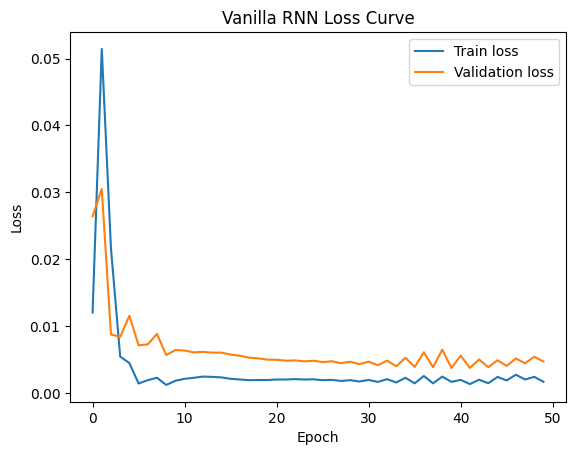

In [192]:
# plot loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla RNN Loss Curve")
plt.legend()
plt.show()

Here we can see the plotted loss. Most likely due to scaling, the values are all small, though we do see an improvement in both train/validation loss in the earlier epochs.

##Part 2: Update RNN With LSTM and GRU

###LSTM Model

In [193]:
# LSTM class
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=1):
    super().__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    # initialize hidden and cell states with 0
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

    # forward propagate, get output of shape (batch_size, sequence_length, hidden_size)
    out, _ = self.lstm(x, (h0, c0))

    # return output of last time step with shape (batch_size, hidden_size)
    out = self.fc(out[:, -1, :])
    return out

In [194]:
# function to create a model
def create_LSTM_model(input_size, hidden_size, output_size, num_layers=1, lr=0.001):
  model = LSTM(input_size, hidden_size, output_size, num_layers).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  return model, criterion, optimizer

In [198]:
# create LSTM
seed_everything(42) # for reproducability
model, criterion, optimizer = create_LSTM_model(x_train_sequences.shape[-1], 128, y_train_sequences.shape[-1], 2)
train_losses, val_losses = train(model, train_loader, criterion, optimizer, 75, 10) # I found that performance improved with more epochs on this model

Epoch 0, Train loss: 0.0212, Val loss: 0.0319
Epoch 10, Train loss: 0.0017, Val loss: 0.0104
Epoch 20, Train loss: 0.0015, Val loss: 0.0089
Epoch 30, Train loss: 0.0014, Val loss: 0.0064
Epoch 40, Train loss: 0.0013, Val loss: 0.0049
Epoch 50, Train loss: 0.0014, Val loss: 0.0065
Epoch 60, Train loss: 0.0017, Val loss: 0.0041
Epoch 70, Train loss: 0.0010, Val loss: 0.0048


In [196]:
# evaluate model
model.eval()
with torch.no_grad():
  pred = model(x_val_sequences)

  # convert from scaled back to original
  pred = scalerY.inverse_transform(pred.cpu().numpy())
  actual = scalerY.inverse_transform(y_val_sequences.cpu().numpy())

  print(f"Validation RMSE: ${root_mean_squared_error(actual, pred):.2f}")

  x_test_sequences = x_test_sequences.to(device)
  y_test_sequences = y_test_sequences.to(device)
  pred = model(x_test_sequences)

  # convert from scaled back to original
  pred = scalerY.inverse_transform(pred.cpu().numpy())
  actual = scalerY.inverse_transform(y_test_sequences.cpu().numpy())

  print(f"Test RMSE: ${root_mean_squared_error(actual, pred):.2f}")

print(f"Max stock price: {max(data["adjHigh"])}")
print(f"Min stock price: {min(data["adjLow"])}")

averageClose = sum(data["adjClose"]) / len(data["adjClose"])
averageOpen = sum(data["adjOpen"]) / len(data["adjOpen"])
print(f"Average stock price for close, open is {averageClose:.2f}, {averageOpen:.2f}")

Validation RMSE: $42.57
Test RMSE: $173.47
Max stock price: 2523.26
Min stock price: 663.284
Average stock price for close, open is 1215.28, 1214.22


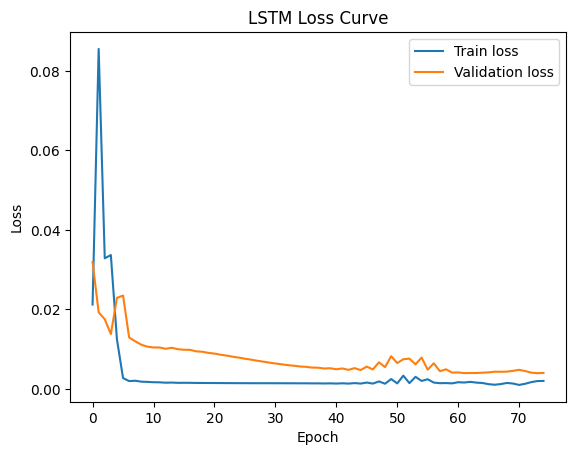

In [197]:
# plot loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Curve")
plt.legend()
plt.show()

###GRU Model

In [202]:
# GRU class
class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=1):
    super().__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    # initialize hidden state with 0
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

    # forward propagate, get output of shape (batch_size, sequence_length, hidden_size)
    out, _ = self.gru(x, h0)

    # return output of last time step with shape (batch_size, hidden_size)
    out = self.fc(out[:, -1, :])
    return out

In [203]:
# function to create a model
def create_GRU_model(input_size, hidden_size, output_size, num_layers=1, lr=0.001):
  model = GRU(input_size, hidden_size, output_size, num_layers).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  return model, criterion, optimizer

In [207]:
# create GRU
seed_everything(42) # for reproducability
model, criterion, optimizer = create_GRU_model(x_train_sequences.shape[-1], 128, y_train_sequences.shape[-1], 2)
train_losses, val_losses = train(model, train_loader, criterion, optimizer, 50, 10)

Epoch 0, Train loss: 0.0069, Val loss: 0.0175
Epoch 10, Train loss: 0.0012, Val loss: 0.0044
Epoch 20, Train loss: 0.0012, Val loss: 0.0036
Epoch 30, Train loss: 0.0012, Val loss: 0.0045
Epoch 40, Train loss: 0.0011, Val loss: 0.0036


In [208]:
# evaluate model
model.eval()
with torch.no_grad():
  pred = model(x_val_sequences)

  # convert from scaled back to original
  pred = scalerY.inverse_transform(pred.cpu().numpy())
  actual = scalerY.inverse_transform(y_val_sequences.cpu().numpy())

  print(f"Validation RMSE: ${root_mean_squared_error(actual, pred):.2f}")

  x_test_sequences = x_test_sequences.to(device)
  y_test_sequences = y_test_sequences.to(device)
  pred = model(x_test_sequences)

  # convert from scaled back to original
  pred = scalerY.inverse_transform(pred.cpu().numpy())
  actual = scalerY.inverse_transform(y_test_sequences.cpu().numpy())

  print(f"Test RMSE: ${root_mean_squared_error(actual, pred):.2f}")

print(f"Max stock price: {max(data["adjHigh"])}")
print(f"Min stock price: {min(data["adjLow"])}")

averageClose = sum(data["adjClose"]) / len(data["adjClose"])
averageOpen = sum(data["adjOpen"]) / len(data["adjOpen"])
print(f"Average stock price for close, open is {averageClose:.2f}, {averageOpen:.2f}")

Validation RMSE: $40.48
Test RMSE: $165.89
Max stock price: 2523.26
Min stock price: 663.284
Average stock price for close, open is 1215.28, 1214.22


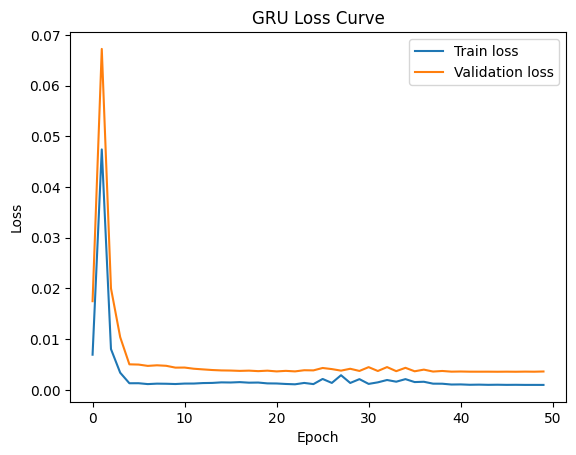

In [209]:
# plot loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Loss Curve")
plt.legend()
plt.show()

###Analysis

I noticed that the LSTM model needed more epochs to train properly as opposed to the basic RNN and GRU models. Out of all 3 models, the GRU model had the best performance (though I didn't do much hyperparameter tuning on any of the models), and the basic RNN had the worst performance.

The main difference between the models is the activation function the model was using to transform the input to the hidden state: `nn.RNN`, `nn.LSTM`, or `nn.GRU`. The RNN and GRU models do not have a (separate) cell state, while the LSTM model does.

Compared to a basic RNN, LSTMs are better at retaining information long-term because of the cell state, which adds a long-term memory path. In addition, memory updates in LSTM are additive instead of multiplicative which can prevent exploding gradients.

The GRU model does not have a separate cell state, but it instead merges the cell state and hidden state to a single hidden state to simplify the architecture. This is different than the basic RNN which doesn't have any cell-state-like structure. Since GRU doesn't have a separate cell state like LSTM, GRU models usually are faster. However, they still retain the benefits of having a cell state since their hidden state maintains long-term information as well.

I believe that LSTM and GRU outperformed RNN due to having better long-term memory. Also, the GRU model was more stable than LSTM when looking at the loss curve--my guess is that perhaps the LSTM having more gates for the data to go through resulted in less stability than the GRU with less gates. LSTM also took more epochs to train, which I believe is due to it being the most complex of the 3 models.

##Part 3: Can We Use a Feed-Forward Network?

Yes, you can use a traditional feed-forward network to solve this problem (actually, a lot of financial models such as those which predict stock prices use MLPs, which is a feed-forward neural network). Time series data, such as this dataset, can be converted to input for a feed-forward network via the sliding window method, which transforms sequences into rows of input features.

The basic idea behind the sliding window method is that you flatten some timestamps into a feature vector, and then you can feed this input to your feed-forward model.

For our 30-day sequence size (with each timestamp having 7 features), we would flatten each sequence of 30 days into a 30 x 7 = 210-feature vector. Now we have usual features to be used in our feed-forward model instead of a sequence, and our target y is just the next timestamp's values after those 30 days. Specifically, each input x contains the input features for days $t-30$ to $t$ and our target y is the target features on day $t+1$.